In [21]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import torch.optim as optim
from torch.nn.utils import spectral_norm
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader

In [17]:
current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


In [2]:
def load_celeba_from_colab(data_path="/content/my_dataset", batch_size=64):
    transformation = transforms.Compose([
        transforms.CenterCrop(178),
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])
    
    print(f"Scanning {data_path} for images...")
    
    train_dataset = datasets.ImageFolder(
        root=data_path, 
        transform=transformation
    )
    
    print(f"Success! Found {len(train_dataset)} high-resolution faces ready for training.")
    
    return DataLoader(dataset=train_dataset, shuffle=True, batch_size=batch_size, drop_last=True, num_workers=2, pin_memory=True)

In [3]:
class StructureEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.LeakyReLU(0.2),   # 64x64 -> 32x32
            nn.Conv2d(32, 64, 4, 2, 1), nn.LeakyReLU(0.2),  # 32x32 -> 16x16
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2), # 16x16 -> 8x8
            nn.Flatten()
        )
        self.mu_head = nn.Linear(128 * 8 * 8, latent_dim)
        self.logvar_head = nn.Linear(128 * 8 * 8, latent_dim)

    def forward(self, x):
        features = self.conv(x)
        return self.mu_head(features), self.logvar_head(features)

In [4]:
class BaseDecoder(nn.Module):
    def __init__(self, latent_dim=64, base_channels=128):
        super().__init__()
        self.base_channels = base_channels
        self.fc = nn.Linear(latent_dim, base_channels * 8 * 8)

    def forward(self, z_s):
        blueprint = self.fc(z_s)
        return blueprint.view(-1, self.base_channels, 8, 8)

In [5]:
class AdaIN(nn.Module):
    def __init__(self, style_dim, num_features):
        super().__init__()
        self.num_features = num_features
        self.style_mlp = nn.Sequential(
            nn.Linear(style_dim, 256), nn.ReLU(),
            nn.Linear(256, num_features * 2)
        )

    def forward(self, x, z_t):
        style_params = self.style_mlp(z_t)
        gamma, beta = style_params.chunk(2, dim=1)
        gamma = gamma.view(-1, self.num_features, 1, 1)
        beta = beta.view(-1, self.num_features, 1, 1)
        x_norm = F.instance_norm(x)
        return x_norm * (1 + gamma) + beta

In [6]:
class ModulatedGenerator(nn.Module):
    def __init__(self, style_dim=64, base_channels=128):
        super().__init__()
        # Block 1: 8x8 -> 16x16
        self.adain1 = AdaIN(style_dim, base_channels)
        self.upconv1 = nn.ConvTranspose2d(base_channels, 64, 4, 2, 1)

        # Block 2: 16x16 -> 32x32
        self.adain2 = AdaIN(style_dim, 64)
        self.upconv2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)

        # Block 3: 32x32 -> 64x64 (RGB Output)
        self.adain3 = AdaIN(style_dim, 32)
        self.upconv3 = nn.ConvTranspose2d(32, 3, 4, 2, 1)

        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, blueprint, z_t):
        x = self.adain1(blueprint, z_t)
        x = self.leaky_relu(x)
        x = self.upconv1(x)

        x = self.adain2(x, z_t)
        x = self.leaky_relu(x)
        x = self.upconv2(x)

        x = self.adain3(x, z_t)
        x = self.leaky_relu(x)
        x = self.upconv3(x)

        return torch.sigmoid(x)

In [7]:
class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(3, 32, 4, 2, 1)), nn.LeakyReLU(0.2),   # 64x64 -> 32x32
            spectral_norm(nn.Conv2d(32, 64, 4, 2, 1)), nn.LeakyReLU(0.2),  # 32x32 -> 16x16
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)), nn.LeakyReLU(0.2), # 16x16 -> 8x8
            nn.Conv2d(128, 1, 3, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

In [8]:
def train_mst_vae_gan_celeba_fast(dataloader, encoder, base_decoder, generator, discriminator, 
                                  opt_G, opt_D, device, epochs, style_dim=64):
    
    print("Starting Lightning-Fast CelebA Training with AMP...")
    
    scaler_G = GradScaler('cuda')
    scaler_D = GradScaler('cuda')
    
    for epoch in range(epochs):
        ep_d_loss, ep_l1_loss, ep_kl_loss, ep_g_adv_loss = 0, 0, 0, 0
        
        for batch, _ in dataloader:
            real_images = batch.to(device, non_blocking=True)
            batch_size = real_images.size(0)
            
            valid = torch.full((batch_size, 1, 8, 8), 0.9, device=device)
            fake = torch.zeros((batch_size, 1, 8, 8), device=device)
            z_t = torch.randn(batch_size, style_dim, device=device)

            # Train Discriminator
            opt_D.zero_grad(set_to_none=True) 
            
            with autocast('cuda'):
                mu, logvar = encoder(real_images)
                std = torch.exp(0.5 * logvar)
                z_s = mu + torch.randn_like(std) * std
                blueprint = base_decoder(z_s)
                fake_images = generator(blueprint, z_t)
                
                real_patch_preds = discriminator(real_images)
                fake_patch_preds = discriminator(fake_images.detach())
                
                # CHANGED: Using binary_cross_entropy_with_logits
                d_loss = (F.binary_cross_entropy_with_logits(real_patch_preds, valid) + 
                          F.binary_cross_entropy_with_logits(fake_patch_preds, fake)) / 2
            
            scaler_D.scale(d_loss).backward()
            scaler_D.step(opt_D)
            scaler_D.update()

            # Train Generator (VAE + GAN Streams)
            opt_G.zero_grad(set_to_none=True)
            
            with autocast('cuda'): # Updated autocast call
                fake_patch_preds_for_G = discriminator(fake_images)
                
                l1_loss = F.l1_loss(fake_images, real_images, reduction='sum') / batch_size
                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
                
                # CHANGED: Using binary_cross_entropy_with_logits
                g_adv_loss = F.binary_cross_entropy_with_logits(fake_patch_preds_for_G, valid)
                
                beta = 1.0    
                gamma = 0.05  
                total_g_loss = l1_loss + (beta * kl_loss) + (gamma * g_adv_loss)
            
            scaler_G.scale(total_g_loss).backward()
            scaler_G.step(opt_G)
            scaler_G.update()
            
            ep_d_loss += d_loss.item()
            ep_l1_loss += l1_loss.item()
            ep_kl_loss += kl_loss.item()
            ep_g_adv_loss += g_adv_loss.item()
            
        num_batches = len(dataloader)
        print(f"Epoch {epoch+1}/{epochs} | D_Loss: {ep_d_loss/num_batches:.3f} | "
              f"L1_Recon: {ep_l1_loss/num_batches:.3f} | KL: {ep_kl_loss/num_batches:.3f} | G_Adv: {ep_g_adv_loss/num_batches:.3f}")

        # Save checkpoints and images!
        if (epoch + 1) % 10 == 0:
            checkpoint_name = f"mst_vae_gan_celeba_epoch_{epoch+1}.pth"
            save_checkpoint(encoder, base_decoder, generator, discriminator, opt_G, opt_D, epoch, filename=checkpoint_name)

In [9]:
def visualize_mst_generation_rgb(encoder, base_decoder, generator, dataloader, device, style_dim=64):
    encoder.eval()
    base_decoder.eval()
    generator.eval()

    real_images, _ = next(iter(dataloader))
    real_images = real_images[:8].to(device)

    with torch.no_grad():
        mu, _ = encoder(real_images)
        blueprint = base_decoder(mu)
        z_t = torch.randn(8, style_dim).to(device)
        generated = generator(blueprint, z_t).cpu()
        real_images = real_images.cpu()

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        # Top Row: Real
        img_real = real_images[i].permute(1, 2, 0).numpy()
        axes[0, i].imshow(img_real)
        axes[0, i].axis("off")
        if i == 0: axes[0, i].set_title("Real Structure")

        # Bottom Row: Generated
        img_gen = generated[i].permute(1, 2, 0).numpy()
        axes[1, i].imshow(img_gen)
        axes[1, i].axis("off")
        if i == 0: axes[1, i].set_title("Generated Output")

    plt.tight_layout()
    plt.show()

    encoder.train()
    base_decoder.train()
    generator.train()

In [10]:
def generate_standalone_images(base_decoder, generator, device, latent_dim=64, style_dim=64, n_images=16):
    """
    Generates completely novel images from pure noise, bypassing the Encoder entirely.
    """
    base_decoder.eval()
    generator.eval()

    with torch.no_grad():
        z_s = torch.randn(n_images, latent_dim).to(device)
        blueprint = base_decoder(z_s)

        z_t = torch.randn(n_images, style_dim).to(device)

        generated = generator(blueprint, z_t).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flatten()):
        img_gen = generated[i].permute(1, 2, 0).numpy()
        ax.imshow(img_gen)
        ax.axis("off")

    plt.suptitle("Standalone CelebA Generations (Pure Noise to Image)", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Return models to training mode
    base_decoder.train()
    generator.train()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

train_dataloader = load_celeba_from_colab(data_path="/content/my_dataset", batch_size=256)

LATENT_DIM = 64
STYLE_DIM = 64

encoder = StructureEncoder(latent_dim=LATENT_DIM).to(device)
base_decoder = BaseDecoder(latent_dim=LATENT_DIM, base_channels=128).to(device)
generator = ModulatedGenerator(style_dim=STYLE_DIM, base_channels=128).to(device)
discriminator = PatchDiscriminator().to(device)

lr = 2e-4
opt_G = optim.Adam(
    list(encoder.parameters()) + list(base_decoder.parameters()) + list(generator.parameters()),
    lr=lr, betas=(0.5, 0.999)
)
opt_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

train_mst_vae_gan_celeba_fast(
    dataloader=train_dataloader,
    encoder=encoder,
    base_decoder=base_decoder,
    generator=generator,
    discriminator=discriminator,
    opt_G=opt_G,
    opt_D=opt_D,
    device=device,
    epochs=10,
    style_dim=STYLE_DIM
)

visualize_mst_generation_rgb(encoder, base_decoder, generator, train_dataloader, device, style_dim=STYLE_DIM)

In [23]:
def load_checkpoint(filename, encoder, base_decoder, generator, discriminator, opt_G=None, opt_D=None, device='cpu'):
    """Loads the model weights from a saved checkpoint, mapping them to the correct hardware."""
    if not os.path.exists(filename):
        print(f"No checkpoint found at {filename}")
        return 0 
    
    print(f"---> Loading checkpoint from {filename} onto {device}")
    
    checkpoint = torch.load(filename, map_location=device, weights_only=True)
    
    encoder.load_state_dict(checkpoint['encoder_state_dict'])
    base_decoder.load_state_dict(checkpoint['base_decoder_state_dict'])
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    
    if opt_G and 'opt_G_state_dict' in checkpoint:
        opt_G.load_state_dict(checkpoint['opt_G_state_dict'])
    if opt_D and 'opt_D_state_dict' in checkpoint:
        opt_D.load_state_dict(checkpoint['opt_D_state_dict'])
        
    return checkpoint.get('epoch', 0)

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [13]:
# Note: Increased latent capacities for human faces
LATENT_DIM = 64
STYLE_DIM = 64

encoder = StructureEncoder(latent_dim=LATENT_DIM).to(device)
base_decoder = BaseDecoder(latent_dim=LATENT_DIM, base_channels=128).to(device)
generator = ModulatedGenerator(style_dim=STYLE_DIM, base_channels=128).to(device)
discriminator = PatchDiscriminator().to(device)

In [18]:
filename = project_root / "data" / "mst_vae_gan_celeba_epoch_60.pth"

In [19]:
filename

PosixPath('/Users/ak007/dissertation/data/mst_vae_gan_celeba_epoch_60.pth')

In [24]:
checkpoint = load_checkpoint(
    filename=str(filename),
    encoder=encoder,
    base_decoder=base_decoder,
    generator=generator,
    discriminator=discriminator,
    device=device
)

---> Loading checkpoint from /Users/ak007/dissertation/data/mst_vae_gan_celeba_epoch_60.pth onto mps


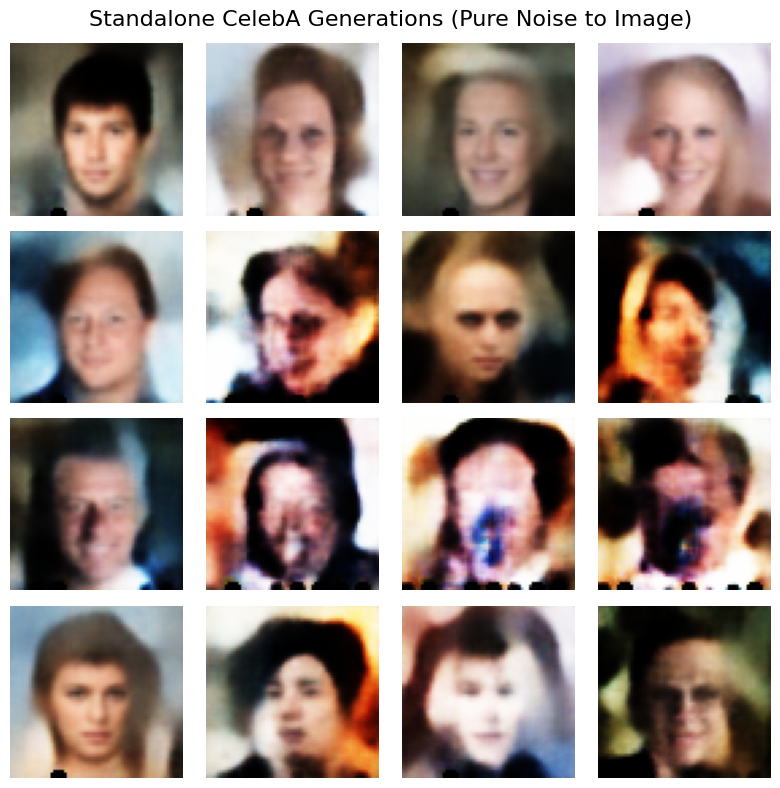

In [31]:
generate_standalone_images(base_decoder, generator, device, latent_dim=64, style_dim=64, n_images=16)